
# Investigating the Overshoot in Casing Simulations

This notebook is a working space to explore the behavior of overshoot observed in casing simulations.
We will set up test cases, run forward simulations, and visualize results to understand the cause.


The above procedure didn't work. Here's a modified try 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


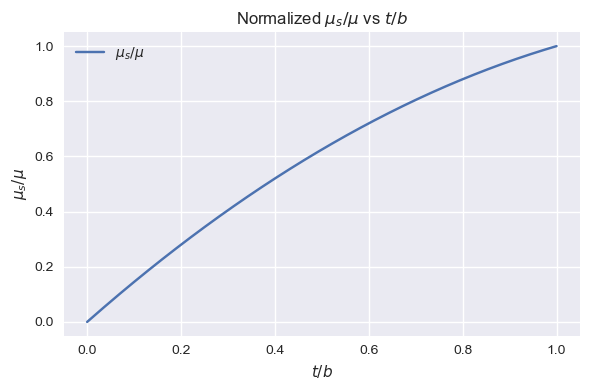

In [13]:
# Parameters
b = 0.10  # outer radius (m)

# Make t/b vary from 0 to 1
t_over_b = np.linspace(0, 1, 200)  # ratio t/b from 0 to 1
t = t_over_b * b

# Normalized μs/μ formula
mu_s_over_mu = (t/(2*b)) * (3 - t/b)

# Plot μs/μ vs t/b
plt.figure(figsize=(6,4))
plt.plot(t_over_b, mu_s_over_mu, label=r'$\mu_s/\mu$')
plt.xlabel(r'$t/b$')
plt.ylabel(r'$\mu_s/\mu$')
plt.title(r'Normalized $\mu_s/\mu$ vs $t/b$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Compute the complex impedance for the thin sheet

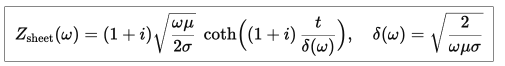

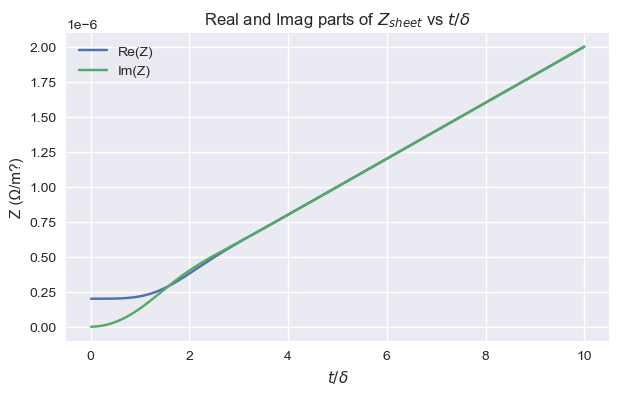

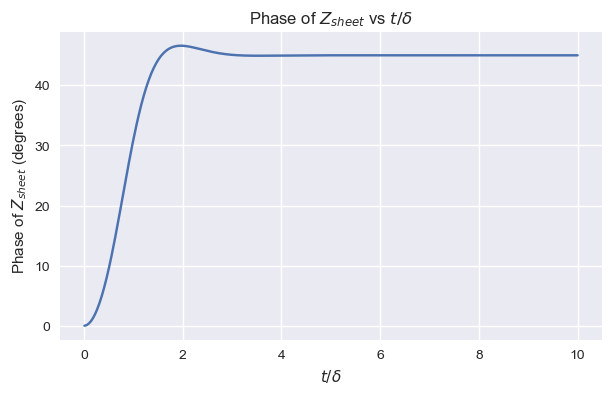

In [14]:

# Parameters (adjust as desired)
mu0   = 4e-7*np.pi
mu_r  = 100.0           # relative μ
sigma = 5e6             # S/m
omega = 2*np.pi*1.0     # reference frequency just to define δ; we override below
mu    = mu0*mu_r

# We'll vary x = t/delta directly, so we don't need ω explicitly
x = np.linspace(0.01, 10, 400)  # t/δ from 0.01 to 10
# For each x, δ = t/x, so ω must satisfy δ = sqrt(2/(ωμσ)) => ω=2/(μσδ^2)
# We'll fix t=1 (arbitrary) and compute ω for each x
t = 1.0
delta = t/x
omega = 2.0/(mu*sigma*delta**2)

# Compute Z_sheet for each x
Z_sheet = (1+1j)*np.sqrt(omega*mu/(2*sigma))*np.cosh((1+1j)*t/delta)/np.sinh((1+1j)*t/delta)

# Real, Imag, Phase
Z_real = np.real(Z_sheet)
Z_imag = np.imag(Z_sheet)
Z_phase_deg = np.angle(Z_sheet, deg=True)

# Plot Re and Im
plt.figure(figsize=(7,4))
plt.plot(x, Z_real, label='Re(Z)')
plt.plot(x, Z_imag, label='Im(Z)')
plt.xlabel(r'$t/\delta$')
plt.ylabel('Z (Ω/m?)')  # adjust units
plt.title('Real and Imag parts of $Z_{sheet}$ vs $t/\\delta$')
plt.grid(True)
plt.legend()

# Plot phase
plt.figure(figsize=(7,4))
plt.plot(x, Z_phase_deg)
plt.xlabel(r'$t/\delta$')
plt.ylabel('Phase of $Z_{sheet}$ (degrees)')
plt.title('Phase of $Z_{sheet}$ vs $t/\\delta$')
plt.grid(True)

plt.show()


### Results from parametric inversion to fine the parameters for a solid cylinder

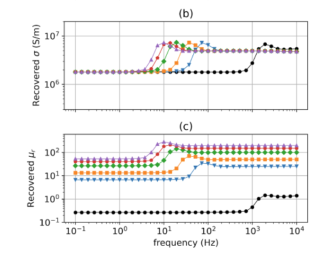



### Rules of thumb for the asymptotic values, the frequency at which the transition occurs, the frequency of the peak induction, frequency of the overshoot and the frequency of the overshoot

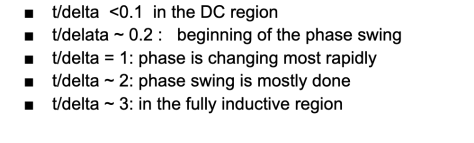


V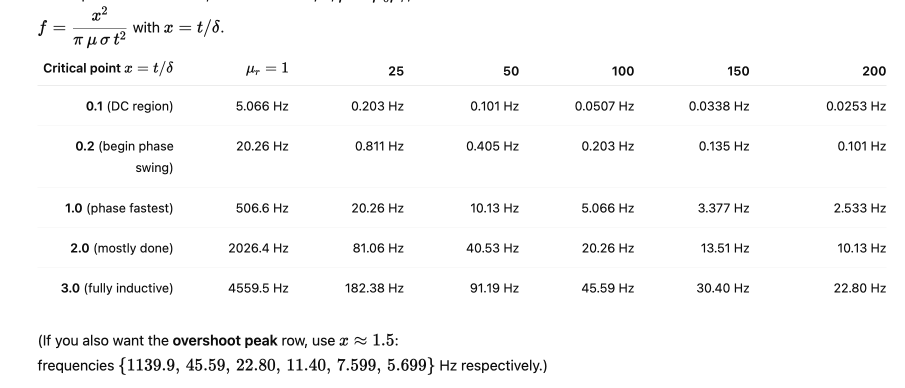

### Exploring the Debye model


### Attempt to fit the mu_eff with a Debye model
Use eye-balled data from the test curve
   (1,26), (5,26), (10,35), (25,60), (45,90), (100,100), (500,100).
   

In [21]:
import numpy as np
from math import pi

# Data
f = np.array([1,5,10,25,45,100,500], dtype=float)
mu_data = np.array([26,26,35,60,90,100,100], dtype=float)
w = 2*pi*f

# Fixed asymptotes
mu_inf = 100.0
mu0 = 26.0
Delta = mu0 - mu_inf  # -74

def mu_model(w, tau):
    return mu_inf + Delta/(1 + (w*tau)**2)

# 1D least squares over tau (simple grid search is enough here)
taus = np.logspace(-4, -1, 2000)  # 0.1 ms to 100 ms
errs = np.sum((mu_model(w[:,None], taus) - mu_data[:,None])**2, axis=0)
tau_best = taus[np.argmin(errs)]
print(f"Best tau ≈ {tau_best:.3e} s")


Best tau ≈ 6.568e-03 s


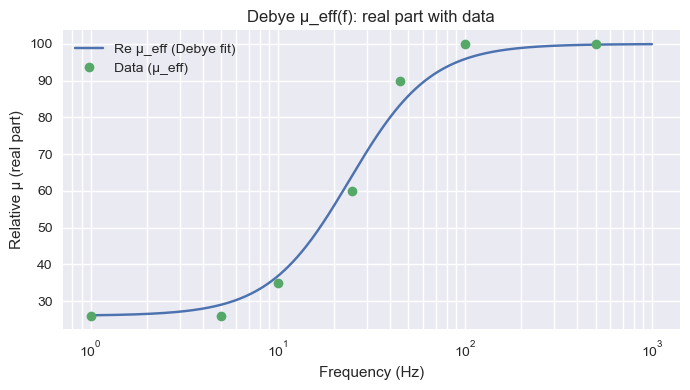

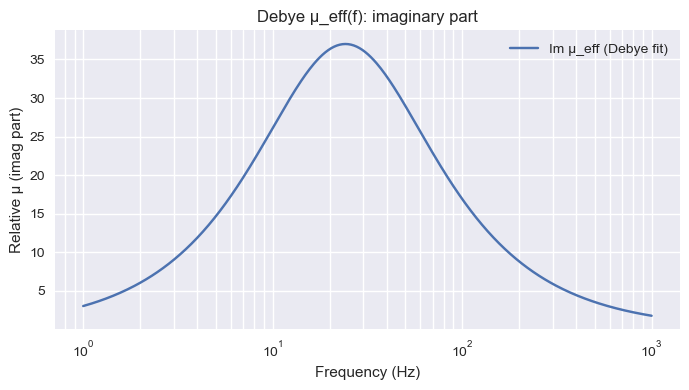

tau = 6.57000e-03 s
Residuals (Re[μ_fit] - μ_data) at data frequencies:
  f=   1.0 Hz:  +0.126
  f=   5.0 Hz:  +3.024
  f=  10.0 Hz:  +1.774
  f=  25.0 Hz:  +4.166
  f=  45.0 Hz:  -6.626
  f= 100.0 Hz:  -4.102
  f= 500.0 Hz:  -0.173


In [20]:
# Debye permeability: plot data and fitted curve
# ------------------------------------------------
# Fixed asymptotes from your notes:
mu_r_inf = 100.0          # high-frequency relative permeability
mu_r0    = 26.0           # low-frequency relative permeability
Delta_mu = mu_r0 - mu_r_inf   # = -74
tau      = 6.57e-3            # seconds (best-fit from your points)



# Debye model (relative permeability)
def mu_r_debye(f_hz, mu_r_inf=mu_r_inf, Delta_mu=Delta_mu, tau=tau):
    w = 2*np.pi*np.asarray(f_hz, dtype=float)
    return mu_r_inf + Delta_mu/(1 + 1j*w*tau)

# Your data (frequency in Hz, mu_eff (relative))
f_data = np.array([1, 5, 10, 25, 45, 100, 500], dtype=float)
mu_data = np.array([26, 26, 35, 60, 90, 100, 100], dtype=float)

# Smooth frequency grid for the curve
f = np.logspace(0, 3, 400)  # 1 Hz to 1000 Hz
mu_curve = mu_r_debye(f)

# ---- Plot: Real part with data points ----
plt.figure(figsize=(7,4))
plt.semilogx(f, np.real(mu_curve), label='Re μ_eff (Debye fit)')
plt.semilogx(f_data, mu_data, 'o', label='Data (μ_eff)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Relative μ (real part)')
plt.title('Debye μ_eff(f): real part with data')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: Imaginary part (model only) ----
plt.figure(figsize=(7,4))
plt.semilogx(f, np.imag(mu_curve), label='Im μ_eff (Debye fit)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Relative μ (imag part)')
plt.title('Debye μ_eff(f): imaginary part')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: report residuals (how well the fit matches the data)
mu_fit_at_data = np.real(mu_r_debye(f_data))
residuals = mu_fit_at_data - mu_data
print(f"tau = {tau:.5e} s")
print("Residuals (Re[μ_fit] - μ_data) at data frequencies:")
for f0, r in zip(f_data, residuals):
    print(f"  f={f0:>6.1f} Hz:  {r:+.3f}")


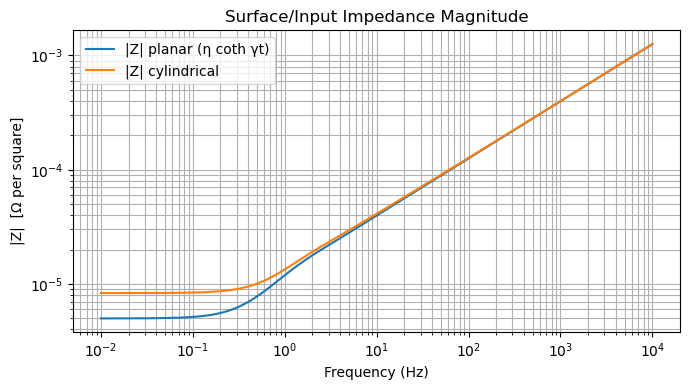

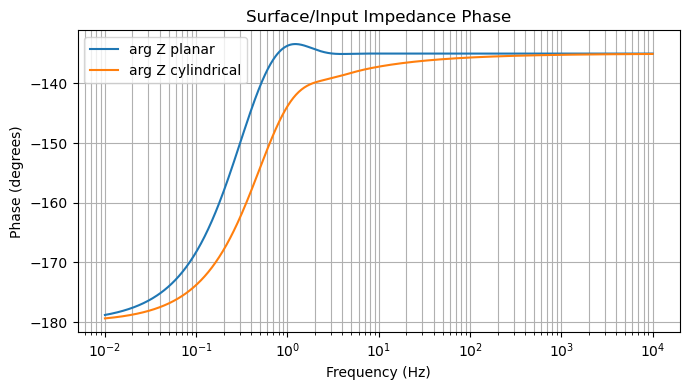

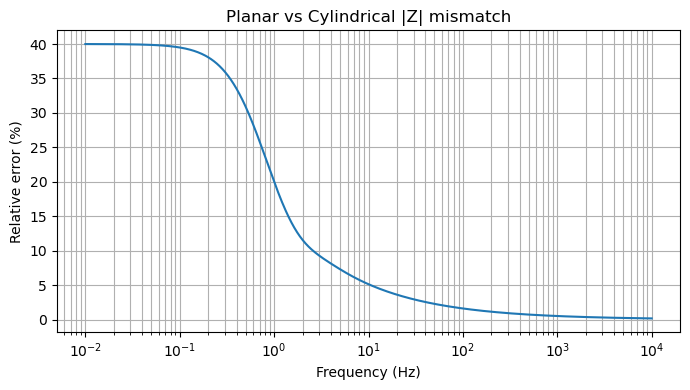

Planar:  low-f limit ~ -5.0004e-06 Ω/□,  high-f |Z| at 10000.0 Hz ~ 1.2566e-03
Cylindrical:  low-f limit ~ -8.3336e-06 Ω/□,  high-f |Z| at 10000.0 Hz ~ 1.2581e-03

Max relative |Z| error over band: 39.99%


In [17]:
# Cylindrical vs Planar sheet impedance — solid & hollow conductors
# Purpose: to find where the planar sheet impedance breaks down when applied to a cylindrical object
# ---------------------------------------------------------------
# Time convention: e^{+i ω t}
# Defaults match your "standard" casing: b=5 cm, t=1 cm, σ=5e6 S/m, μr=100

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv  # modified Bessel Iν, Kν

# -------- Parameters (EDIT) --------
mu0 = 4e-7*np.pi
mu_r = 100.0
mu = mu0*mu_r
sigma = 5e6           # S/m
eps = 0.0             # F/m (steel: displacement negligible here)
b = 0.05              # outer radius [m]
t = 0.04              # wall thickness [m]
a = b - t             # inner radius [m]; set a=0 for solid
f = np.logspace(-2, 4, 600)   # Hz
w = 2*np.pi*f

# -------- Helpers --------
def admittivity(omega, sigma=sigma, eps=eps):
    return sigma + 1j*omega*eps

def gamma2(omega, mu=mu, sigma=sigma, eps=eps):
    return np.sqrt(1j*omega*mu*admittivity(omega, sigma, eps))

def eta2(omega, mu=mu, sigma=sigma, eps=eps):
    g = gamma2(omega, mu, sigma, eps)
    return 1j*omega*mu / g

def Z_sheet_planar(omega, t=t, mu=mu, sigma=sigma, eps=eps):
    g = gamma2(omega, mu, sigma, eps)
    eta = 1j*omega*mu / g
    return eta * 1/np.tanh(-g*t)  # = eta * coth(g t)

def Z_solid_cyl(omega, b=b, mu=mu, sigma=sigma, eps=eps):
    """Solid cylinder (a=0): Z = (iωμ/γ) * I0(γ b)/I1(γ b)"""
    g = gamma2(omega, mu, sigma, eps)
    num = iv(0, g*b)
    den = iv(1, g*b)
    return (1j*omega*mu/g) * (num/den)

def Z_shell_open_cyl(omega, a=a, b=b, mu=mu, sigma=sigma, eps=eps):
    """
    Hollow cylinder with 'open' bore at r=a (Hφ(a)≈0):
    Z = (iωμ/γ) * [I0(γ b) + α K0(γ b)] / [α K1(γ b) - I1(γ b)],
    where α = I1(γ a) / K1(γ a).
    """
    g = gamma2(omega, mu, sigma, eps)
    I0b, I1b = iv(0, g*b), iv(1, g*b)
    K0b, K1b = kv(0, g*b), kv(1, g*b)
    Ia1, Ka1 = iv(1, g*a), kv(1, g*a)
    # handle a=0 limit safely: α -> 0 because K1(γ a)→∞
    alpha = np.where(a > 0, Ia1/Ka1, 0.0)
    num = I0b + alpha*K0b
    den = alpha*K1b - I1b
    return (1j*omega*mu/g) * (num/den)

# -------- Compute --------
Z_planar = Z_sheet_planar(w)
Z_cyl_hollow = Z_shell_open_cyl(w, a=a, b=b)
Z_cyl_solid  = Z_solid_cyl(w, b=b)  # only meaningful if a=0 (solid)

# Choose which cylindrical to compare against planar
use_hollow = True  # set False to compare planar vs solid
Z_cyl = Z_cyl_hollow if use_hollow else Z_cyl_solid

# Relative error (complex): |Z_cyl - Z_planar| / |Z_cyl|
rel_err = np.abs(Z_cyl - Z_planar)/np.maximum(np.abs(Z_cyl), 1e-30)

# -------- Plots --------
plt.figure(figsize=(7,4))
plt.loglog(f, np.abs(Z_planar), label='|Z| planar (η coth γt)')
plt.loglog(f, np.abs(Z_cyl),    label='|Z| cylindrical')
plt.xlabel('Frequency (Hz)'); plt.ylabel('|Z|  [Ω per square]')
plt.title('Surface/Input Impedance Magnitude')
plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.semilogx(f, np.angle(Z_planar, deg=True), label='arg Z planar')
plt.semilogx(f, np.angle(Z_cyl, deg=True),    label='arg Z cylindrical')
plt.xlabel('Frequency (Hz)'); plt.ylabel('Phase (degrees)')
plt.title('Surface/Input Impedance Phase')
plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
plt.semilogx(f, 100*rel_err)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Relative error (%)')
plt.title('Planar vs Cylindrical |Z| mismatch')
plt.grid(True, which='both'); plt.tight_layout(); plt.show()

# -------- Quick numeric summaries --------
def summarize(name, Z):
    print(f"{name}:  low-f limit ~ {np.real(Z[0]):.4e} Ω/□,  high-f |Z| at {f[-1]:.1f} Hz ~ {np.abs(Z[-1]):.4e}")
summarize("Planar", Z_planar)
summarize("Cylindrical", Z_cyl)

print(f"\nMax relative |Z| error over band: {100*np.max(rel_err):.2f}%")


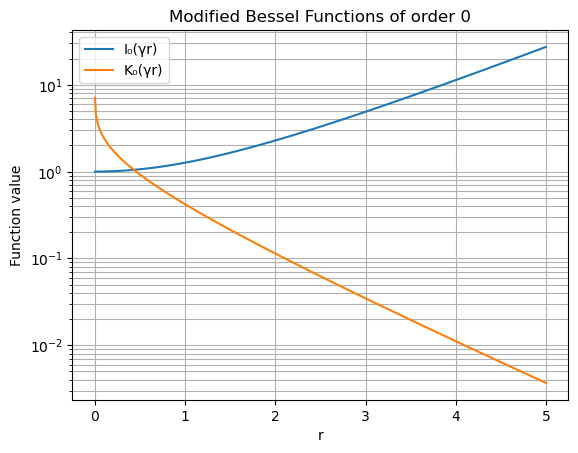

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, k0

r = np.linspace(0.001, 5, 500)
gamma = 1.0
plt.semilogy(r, i0(gamma*r), label='I₀(γr)')
plt.semilogy(r, k0(gamma*r), label='K₀(γr)')
plt.xlabel('r'); plt.ylabel('Function value')
plt.title('Modified Bessel Functions of order 0')
plt.legend(); plt.grid(True, which='both')
plt.show()


# Surface impedance for various casings
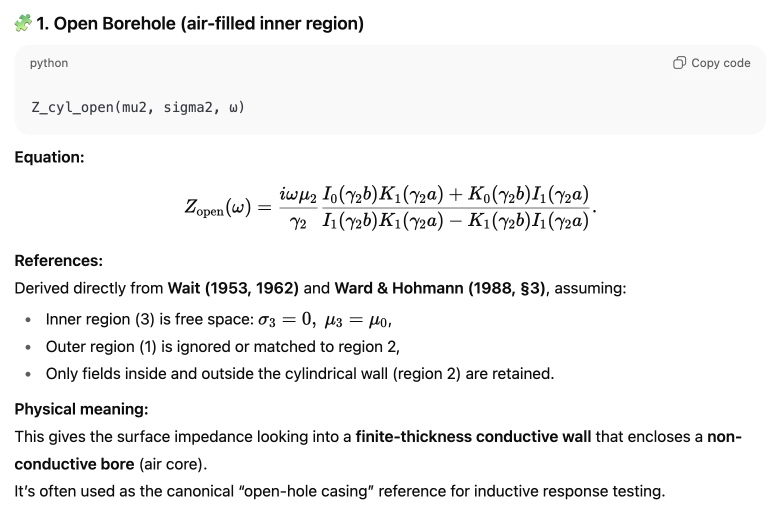
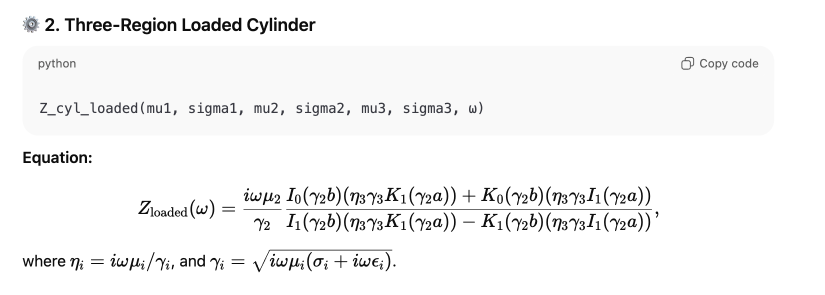
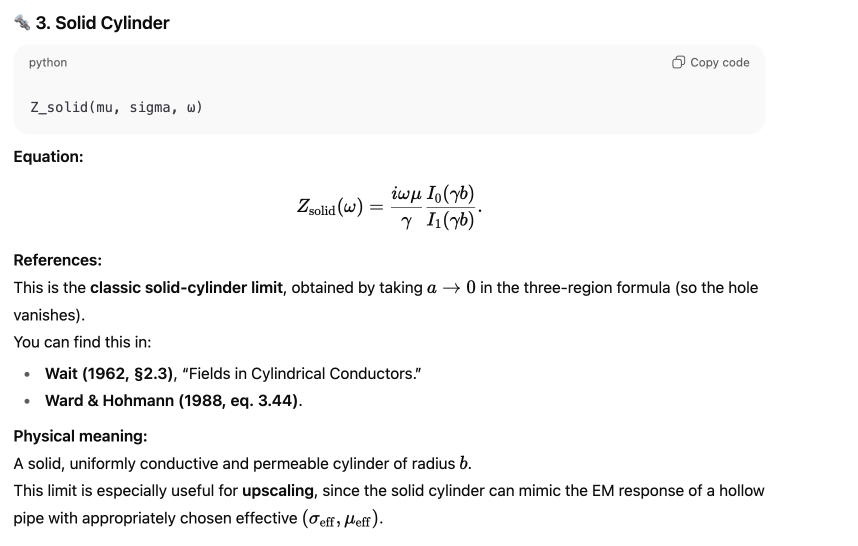

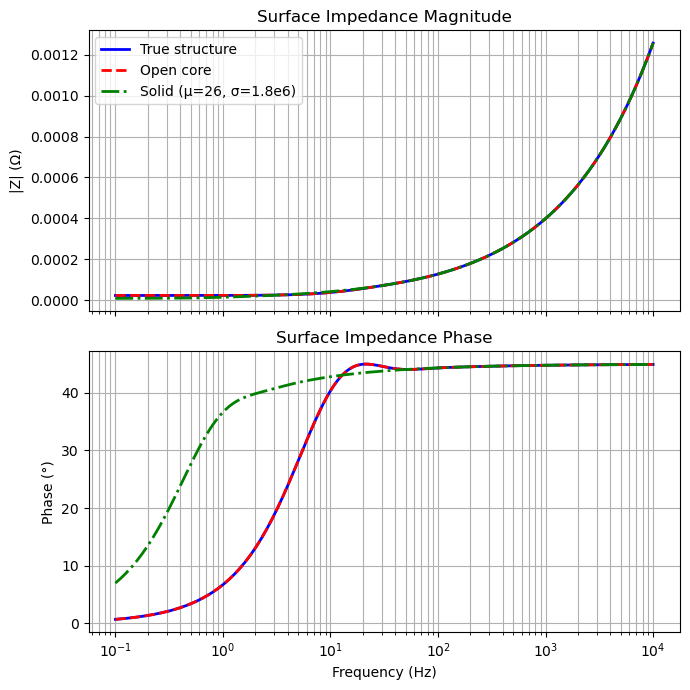

0.1

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv

# --- Physical constants
mu0 = 4*np.pi*1e-7
eps0 = 8.854187817e-12

# --- Geometry
b = 0.05        # outer radius [m]
t = 0.01        # wall thickness [m]
a = b - t

# --- Frequency range
f = np.logspace(-1, 4, 200)   # 0.1 Hz – 10 kHz
w = 2*np.pi*f

# --- Helper: complex propagation constant
def gamma(mu, sigma, omega):
    return np.sqrt(1j*omega*mu*(sigma + 1j*omega*eps0))

# --- Cylindrical surface impedance (open bore)

def Z_cyl_open(mu2, sigma2, omega):
    """Open core (region 3 = air, no conductor)"""
    g2 = gamma(mu2, sigma2, omega)
    I0b, I1b = iv(0, g2*b), iv(1, g2*b)
    K0b, K1b = kv(0, g2*b), kv(1, g2*b)
    I1a, K1a = iv(1, g2*a), kv(1, g2*a)
    num = I0b*K1a + K0b*I1a
    den = I1b*K1a - K1b*I1a
    return (1j*omega*mu2/g2)*(num/den)

# --- Cylindrical surface impedance (3-region symmetric medium)
def Z_cyl_loaded(mu1, sigma1, mu2, sigma2, mu3, sigma3, omega):
    """Full 3-region impedance, loaded both sides"""
    g1 = gamma(mu1, sigma1, omega)
    g2 = gamma(mu2, sigma2, omega)
    g3 = gamma(mu3, sigma3, omega)
    eta1 = 1j*omega*mu1/g1
    eta3 = 1j*omega*mu3/g3

    I0b, I1b = iv(0, g2*b), iv(1, g2*b)
    K0b, K1b = kv(0, g2*b), kv(1, g2*b)
    I1a, K1a = iv(1, g2*a), kv(1, g2*a)

    num = I0b*(eta3*g3*K1a) + K0b*(eta3*g3*I1a)
    den = I1b*(eta3*g3*K1a) - K1b*(eta3*g3*I1a)
    return (1j*omega*mu2/g2)*(num/den)
#
# --- Cylindrical surface impedance for solid cylinder
def Z_solid(mu, sigma, omega):
    g = gamma(mu, sigma, omega)
    I0b, I1b = iv(0, g*b), iv(1, g*b)
    return (1j*omega*mu/g)*(I0b/I1b)

# --- Scenarios
mu_air = mu0
sigma_air = 0.0

# True 3-region structure
Z_true = Z_cyl_loaded(mu0, 0.1, mu0*100, 5e6, mu0, 0.01, w)

# Open core (air inside)
Z_open = Z_cyl_open(mu0*100, 5e6, w)

# Solid equivalent cylinder
# Z_solidcase = Z_solid(mu0*26, 1.8e6, w)
Z_solidcase = Z_solid(mu0*100, 5.e6, w)

# --- Plot results
fig, ax = plt.subplots(2, 1, figsize=(7,7), sharex=True)

ax[0].semilogx(f, np.abs(Z_true), 'b', lw=2, label='True structure')
ax[0].semilogx(f, np.abs(Z_open), 'r--', lw=2, label='Open core')
ax[0].semilogx(f, np.abs(Z_solidcase), 'g-.', lw=2, label='Solid (μ=26, σ=1.8e6)')
ax[0].set_ylabel('|Z| (Ω)')
ax[0].set_title('Surface Impedance Magnitude')
ax[0].grid(True, which='both')
ax[0].legend()

ax[1].semilogx(f, np.angle(Z_true, deg=True), 'b', lw=2)
ax[1].semilogx(f, np.angle(Z_open, deg=True), 'r--', lw=2)
ax[1].semilogx(f, np.angle(Z_solidcase, deg=True), 'g-.', lw=2)
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Phase (°)')
ax[1].set_title('Surface Impedance Phase')
ax[1].grid(True, which='both')

plt.tight_layout()
plt.show()
sigma1
sigma2
sigma3

###  takeaways;   the solid cylinder does not capture the phase bump for (mu=.26 and sigma=1.8 e6)
very bad low frequency 


In [ ]:
# (Code block produced in the notebook above)
# It defines:
# - Z_in_general(...)  (three-region input impedance at r=b)
# - mu_eff_debye(ω, μ_inf, Δμ, τ)
# - Global least-squares fit for [σ_eff, μ_inf, Δμ, τ]
# - Plots and saves CSV to /mnt/data/debye_fit_results.csv


In [ ]:
sigma_eff  = 3.3626e+06 S/m
mu_inf     = 66.173
Delta mu   = -88.243
tau_mu     = 7.6494e-03 s   (f_c ≈ 20.81 Hz)
cost (L2)  = 3.3094e-08


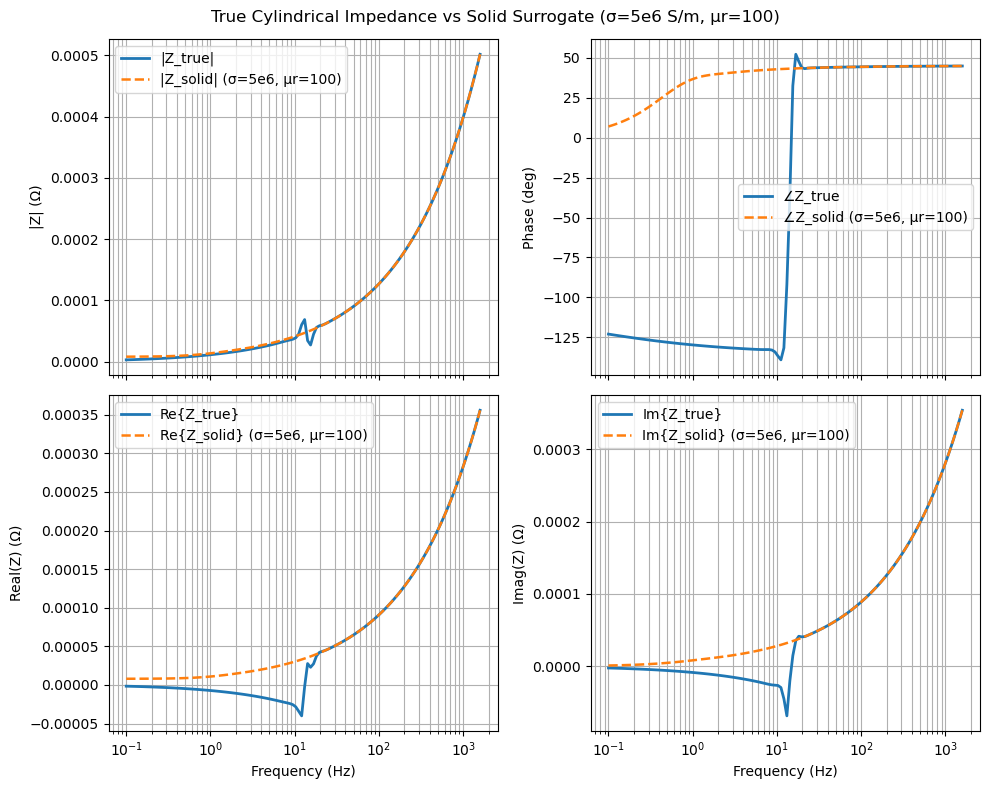

=== Global Debye fit (μ Debye, constant σ) ===
sigma_eff = 3.3626e+06 S/m
mu_inf    = 66.173
Delta mu  = -88.243
tau_mu    = 7.6494e-03 s  (f_c ≈ 20.81 Hz)
cost      = 3.3094e-08
Wrote CSVs: upscale_perfreq_fit.csv, debye_fit_results.csv


In [12]:

# (same content as last attempt)
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv, kv
from scipy.optimize import least_squares

mu0  = 4e-7 * np.pi
eps0 = 8.854187817e-12

a = 0.04
b = 0.05
t = b - a

sigma1, mu1 = 0.1, mu0
sigma2, mu2 = 5e6, 100*mu0
sigma3, mu3 = 0.1, mu0

f = np.logspace(-1, 3.2, 120)
w = 2*np.pi*f

def gamma_from(mu, sigma, omega, eps):
    return np.sqrt(1j * omega * mu * (sigma + 1j*omega*eps))

def Z_in_general(omega, a, b, mu1, sigma1, mu2, sigma2, mu3, sigma3, eps1=eps0, eps2=0.0, eps3=eps0):
    g1 = gamma_from(mu1, sigma1, omega, eps1)
    g2 = gamma_from(mu2, sigma2, omega, eps2)
    g3 = gamma_from(mu3, sigma3, omega, eps3)
    eta1 = 1j * omega * mu1 / g1
    eta2 = 1j * omega * mu2 / g2
    eta3 = 1j * omega * mu3 / g3

    I0b, I1b = iv(0, g2*b), iv(1, g2*b)
    K0b, K1b = kv(0, g2*b), kv(1, g2*b)
    I1a_g1, K1a_g1 = iv(1, g1*a), kv(1, g1*a)
    I1a_g2, K1a_g2 = iv(1, g2*a), kv(1, g2*a)
    I1a_g3, K1a_g3 = iv(1, g3*a), kv(1, g3*a)

    A = eta3*g2*(K1a_g3*I1a_g1 - I1a_g3*K1a_g1) + eta1*g3*(I1a_g3*K1a_g2 - K1a_g3*I1a_g2)
    B = eta3*g2*(K1a_g3*K1a_g1 - I1a_g3*I1a_g1) + eta1*g3*(I1a_g3*I1a_g2 - K1a_g3*K1a_g2)

    Zin = (1j * omega * mu2 / g2) * (I0b*A + K0b*B) / (I1b*A - K1b*B)
    return Zin

def Z_solid(omega, b, mu_eff, sigma_eff, eps_eff=0.0):
    g = gamma_from(mu_eff, sigma_eff, omega, eps_eff)
    I0b, I1b = iv(0, g*b), iv(1, g*b)
    return (1j * omega * mu_eff / g) * (I0b / I1b)

Z_true = np.array([
    Z_in_general(ww, a, b, mu1, sigma1, mu2, sigma2, mu3, sigma3, eps1=eps0, eps2=0.0, eps3=eps0)
    for ww in w
])
# compute a Z from a potential solid cylinder and plot the impedances
# === Add this right after Z_true is computed ===
# Reference solid with fixed sigma, mu
sigma_eff_ref = 5e6
mu_eff_ref    = 100.0 * mu0
Z_solid_ref = np.array([ Z_solid(ww, b, mu_eff_ref, sigma_eff_ref, eps_eff=0.0) for ww in w ])

# Four-panel plot: |Z|, phase, Re, Im (true vs reference solid)
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

# Magnitude
ax[0, 0].semilogx(f, np.abs(Z_true), lw=2, label='|Z_true|')
ax[0, 0].semilogx(f, np.abs(Z_solid_ref), lw=1.8, ls='--',
                  label='|Z_solid| (σ=5e6, μr=100)')
ax[0, 0].set_ylabel('|Z| (Ω)')
ax[0, 0].grid(True, which='both')
ax[0, 0].legend()

# Phase (deg)
ax[0, 1].semilogx(f, np.angle(Z_true, deg=True), lw=2, label='∠Z_true')
ax[0, 1].semilogx(f, np.angle(Z_solid_ref, deg=True), lw=1.8, ls='--',
                  label='∠Z_solid (σ=5e6, μr=100)')
ax[0, 1].set_ylabel('Phase (deg)')
ax[0, 1].grid(True, which='both')
ax[0, 1].legend()

# Real
ax[1, 0].semilogx(f, Z_true.real, lw=2, label='Re{Z_true}')
ax[1, 0].semilogx(f, Z_solid_ref.real, lw=1.8, ls='--',
                  label='Re{Z_solid} (σ=5e6, μr=100)')
ax[1, 0].set_xlabel('Frequency (Hz)')
ax[1, 0].set_ylabel('Real(Z) (Ω)')
ax[1, 0].grid(True, which='both')
ax[1, 0].legend()

# Imag
ax[1, 1].semilogx(f, Z_true.imag, lw=2, label='Im{Z_true}')
ax[1, 1].semilogx(f, Z_solid_ref.imag, lw=1.8, ls='--',
                  label='Im{Z_solid} (σ=5e6, μr=100)')
ax[1, 1].set_xlabel('Frequency (Hz)')
ax[1, 1].set_ylabel('Imag(Z) (Ω)')
ax[1, 1].grid(True, which='both')
ax[1, 1].legend()

fig.suptitle('True Cylindrical Impedance vs Solid Surrogate (σ=5e6 S/m, μr=100)', y=0.98)
plt.tight_layout()
plt.show()


def fit_solid_params_single_freq(omega, b, Z_target, init=(5e6, 100.0)):
    def residuals(x):
        sigma_eff = np.clip(x[0], 1e3, 1e9)
        mu_r_eff  = np.clip(x[1],  1.0, 2000.0)
        mu_eff = mu0 * mu_r_eff
        Zs = Z_solid(omega, b, mu_eff, sigma_eff, eps_eff=0.0)
        diff = Zs - Z_target
        return np.array([diff.real, diff.imag])

    lb = np.array([1e3, 1.0])
    ub = np.array([1e9, 2000.0])
    x0 = np.array(init, dtype=float)
    res = least_squares(residuals, x0, bounds=(lb, ub), xtol=1e-12, ftol=1e-12, gtol=1e-12, max_nfev=600)
    return res.x, res.cost

sigma_eff_pf = []
mu_r_eff_pf  = []
x_curr = np.array([5e6, 100.0], dtype=float)
for Zi, ww in zip(Z_true, w):
    x_opt, _ = fit_solid_params_single_freq(ww, b, Zi, init=x_curr)
    sigma_eff_pf.append(float(x_opt[0]))
    mu_r_eff_pf.append(float(x_opt[1]))
    x_curr = x_opt

sigma_eff_pf = np.array(sigma_eff_pf)
mu_r_eff_pf  = np.array(mu_r_eff_pf)

def mu_eff_debye(omega, mu_inf, dmu, tau):
    return mu0 * (mu_inf + dmu / (1.0 + 1j * omega * tau))

def Z_model_debye(params, wvec):
    sigma_eff, mu_inf, dmu, log10_tau = params
    tau = 10.0**log10_tau
    mu_eff = mu_eff_debye(wvec, mu_inf, dmu, tau)
    Zs = np.array([ Z_solid(ww, b, mu_eff[k], sigma_eff) for k, ww in enumerate(wvec) ])
    return Zs

def residuals_debye(params, wvec, Zt):
    Zs = Z_model_debye(params, wvec)
    diff = Zs - Zt
    return np.hstack([diff.real, diff.imag])

mu_inf0 = 100.0
dmu0    = -80.0
omega_c0 = 2.0 / (mu0*mu_inf0*sigma2*t**2)
tau0 = 1.0 / omega_c0
sigma0 = 5e6

x0 = np.array([sigma0, mu_inf0, dmu0, np.log10(tau0)], dtype=float)
lb = np.array([1e4,   1.0,  -1e4, -6.0])
ub = np.array([1e9, 2000.0,  1e4,  4.0])

res = least_squares(residuals_debye, x0, bounds=(lb, ub),
                    args=(w, Z_true),
                    xtol=1e-12, ftol=1e-12, gtol=1e-12, max_nfev=4000)

sigma_eff_g, mu_inf_g, dmu_g, log10_tau_g = res.x
tau_g = 10.0**log10_tau_g
Z_fit = Z_model_debye(res.x, w)

print("=== Global Debye fit (μ Debye, constant σ) ===")
print(f"sigma_eff = {sigma_eff_g:.4e} S/m")
print(f"mu_inf    = {mu_inf_g:.3f}")
print(f"Delta mu  = {dmu_g:.3f}")
print(f"tau_mu    = {tau_g:.4e} s  (f_c ≈ {1/(2*np.pi*tau_g):.2f} Hz)")
print(f"cost      = {res.cost:.4e}")

# Save CSVs (you can comment out if not needed)
np.savetxt("upscale_perfreq_fit.csv",
           np.column_stack([f, Z_true.real, Z_true.imag, sigma_eff_pf, mu_r_eff_pf]),
           delimiter=",",
           header="f_Hz,ReZ_true_Ohm,ImZ_true_Ohm,sigma_eff_Sperm,mu_r_eff",
           comments="")

np.savetxt("debye_fit_results.csv",
           np.column_stack([f, np.abs(Z_true), np.abs(Z_fit), np.angle(Z_true), np.angle(Z_fit),
                            Z_true.real, Z_fit.real, Z_true.imag, Z_fit.imag]),
           delimiter=",",
           header="f_Hz,|Z_true|,|Z_fit|,angle_true(rad),angle_fit(rad),ReZ_true,ReZ_fit,ImZ_true,ImZ_fit",
           comments="")

print("Wrote CSVs: upscale_perfreq_fit.csv, debye_fit_results.csv")


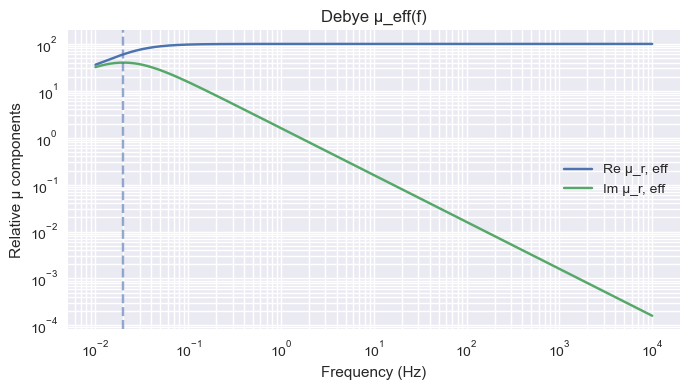

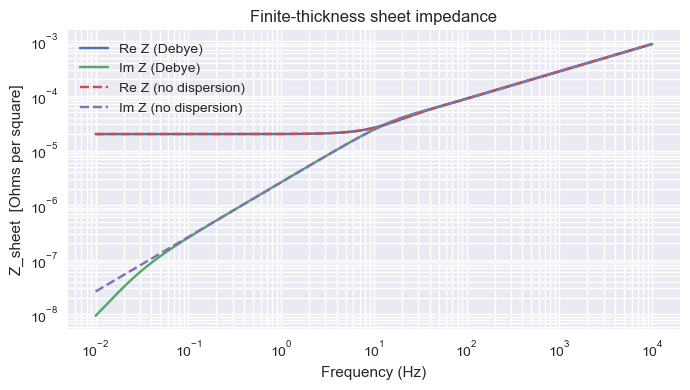

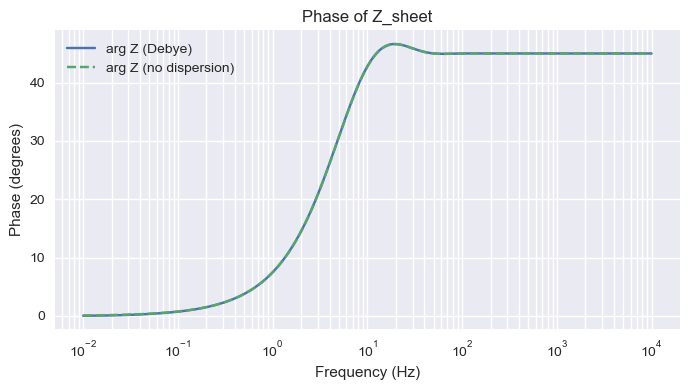

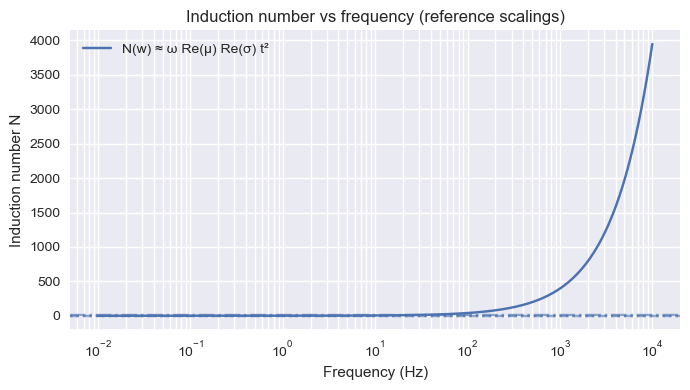

Reference (no dispersion) scalings for your parameters:
  f(N=1)      ≈ 2.53 Hz
  f(δ = t)    ≈ 5.07 Hz
  Debye knee f0 = 1/(2π τ_mu) ≈ 0.02 Hz


In [16]:
# Debye sheet-impedance demo for a steel casing (axisymmetric, finite thickness)
# You can tweak the parameters in the block below and re-run the cell.

import numpy as np
import matplotlib.pyplot as plt

# ------- Parameters (EDIT THESE) -------
mu0 = 4e-7*np.pi                 # H/m
t   = 0.01                       # wall thickness [m]
sigma_inf = 5e6                  # high-frequency (and DC if no dispersion) conductivity [S/m]

# Debye permeability (enable by setting Delta_mu != 0)
mu_r_inf = 100.0                 # high-frequency relative mu (plateau as f -> infinity)
Delta_mu = -80.0                  # extra low-f permeability so mu_r(0) = mu_r_inf + Delta_mu
# Good initial guess for tau_mu: center near N~2 (≈ δ=t)
#tau_mu   = 1.0 / (2.0*np.pi* (2.0) * mu0*mu_r_inf*sigma_inf*t**2) * 2.0*np.pi

# Optional Debye conductivity (usually keep zero)
Delta_sigma = 0.0                # [S/m] extra DC conductivity, sigma(0) = sigma_inf + Delta_sigma
tau_sigma   = tau_mu             # you can set a different relaxation if needed

# Frequency range
f = np.logspace(-2, 4, 600)      # Hz
w = 2*np.pi*f

# ------- Helper functions -------
def mu_eff(w):
    # single-pole Debye for mu
    return mu0*(mu_r_inf + Delta_mu/(1+1j*w*tau_mu))

def sigma_eff(w):
    # single-pole Debye for sigma (set Delta_sigma=0 for constant sigma=sigma_inf)
    return sigma_inf + Delta_sigma/(1+1j*w*tau_sigma)

def delta_skin(w, muw, sigw):
    return np.sqrt(2/(w*muw*sigw))

def coth(z):
    return 1/np.tanh(z)

def Z_sheet(w):
    muw = mu_eff(w)
    sigw = sigma_eff(w)
    delta = delta_skin(w, muw, sigw)
    return (1+1j)*np.sqrt(w*muw/(2*sigw))*coth((1+1j)*t/delta)

# Reference (no dispersion) for comparison
def Z_sheet_ref(w):
    muw = mu0*mu_r_inf
    sigw = sigma_inf
    delta = np.sqrt(2/(w*muw*sigw))
    return (1+1j)*np.sqrt(w*muw/(2*sigw))*coth((1+1j)*t/delta)

# ------- Compute curves -------
Z = Z_sheet(w)
Zref = Z_sheet_ref(w)

muw = mu_eff(w)
sigw = sigma_eff(w)

# ------- Plots -------
# 1) mu_eff(f) real/imag
plt.figure(figsize=(7,4))
plt.loglog(f, np.real(muw)/mu0, label='Re μ_r, eff')
plt.loglog(f, np.imag(muw)/mu0, label='Im μ_r, eff')
plt.axvline(1/(2*np.pi*tau_mu), linestyle='--', alpha=0.6)  # Debye knee
plt.xlabel('Frequency (Hz)')
plt.ylabel('Relative μ components')
plt.title('Debye μ_eff(f)')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Z_sheet real/imag with and without dispersion
plt.figure(figsize=(7,4))
plt.loglog(f, np.real(Z), label='Re Z (Debye)')
plt.loglog(f, np.imag(Z), label='Im Z (Debye)')
plt.loglog(f, np.real(Zref), linestyle='--', label='Re Z (no dispersion)')
plt.loglog(f, np.imag(Zref), linestyle='--', label='Im Z (no dispersion)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Z_sheet  [Ohms per square]')
plt.title('Finite-thickness sheet impedance')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Phase of Z_sheet
phase_deg = np.angle(Z, deg=True)
phase_ref = np.angle(Zref, deg=True)
plt.figure(figsize=(7,4))
plt.semilogx(f, phase_deg, label='arg Z (Debye)')
plt.semilogx(f, phase_ref, linestyle='--', label='arg Z (no dispersion)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (degrees)')
plt.title('Phase of Z_sheet')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# 4) Induction number N (using real parts for a quick indicator)
N = w*np.real(muw)*np.real(sigw)*t**2
plt.figure(figsize=(7,4))
plt.semilogx(f, N, label='N(w) ≈ ω Re(μ) Re(σ) t²')
plt.axhline(0.5, linestyle=':', alpha=0.6)
plt.axhline(2.0, linestyle='--', alpha=0.6)
plt.axhline(5.0, linestyle='-.', alpha=0.6)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Induction number N')
plt.title('Induction number vs frequency (reference scalings)')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# Print a few reference frequencies (no-dispersion scalings)
f_N1 = 1/(2*np.pi*mu0*mu_r_inf*sigma_inf*t**2)
f_delta_eq_t = 2*f_N1
print(f"Reference (no dispersion) scalings for your parameters:")
print(f"  f(N=1)      ≈ {f_N1:.3g} Hz")
print(f"  f(δ = t)    ≈ {f_delta_eq_t:.3g} Hz")
print(f"  Debye knee f0 = 1/(2π τ_mu) ≈ {1/(2*np.pi*tau_mu):.3g} Hz")
